# House Prices – Regressão
## Etapa 2: Engenharia de Features, Modelagem, Regras de Negócio, Avaliação e Conclusão

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.pipeline import Pipeline
from xgboost import XGBRegressor
import os

os.makedirs('../outputs/figures', exist_ok=True)
os.makedirs('../outputs/models', exist_ok=True)

plt.rcParams['figure.dpi'] = 120
sns.set_theme(style='whitegrid')

print('Imports OK')

Imports OK


---
# 1. Carregamento dos Dados

In [2]:
train = pd.read_csv('../data/raw/train.csv')
test  = pd.read_csv('../data/raw/test.csv')

print(f'Train: {train.shape}  |  Test: {test.shape}')
print(f'Variáveis: {train.shape[1]} colunas, sendo 1 alvo (SalePrice)')

Train: (1460, 81)  |  Test: (1459, 80)
Variáveis: 81 colunas, sendo 1 alvo (SalePrice)


---
# 2. Engenharia de Features

## 2.1 Tratamento de Valores Ausentes

In [3]:
# Colunas onde NA significa 'sem o recurso'
NONE_COLS = [
    'Alley','BsmtQual','BsmtCond','BsmtExposure','BsmtFinType1','BsmtFinType2',
    'FireplaceQu','GarageType','GarageFinish','GarageQual','GarageCond',
    'PoolQC','Fence','MiscFeature','MasVnrType'
]

def tratar_nulos(df):
    df = df.copy()
    for col in NONE_COLS:
        if col in df.columns:
            df[col] = df[col].fillna('None')
    # Numéricas com NA → mediana
    num_cols = df.select_dtypes(include=np.number).columns
    df[num_cols] = df[num_cols].fillna(df[num_cols].median())
    # Categóricas restantes → moda
    cat_cols = df.select_dtypes(include='object').columns
    for col in cat_cols:
        df[col] = df[col].fillna(df[col].mode()[0])
    return df

train = tratar_nulos(train)
test  = tratar_nulos(test)

print(f'Nulos restantes – train: {train.isnull().sum().sum()} | test: {test.isnull().sum().sum()}')

Nulos restantes – train: 0 | test: 0


## 2.2 Criação de Novas Features

In [4]:
def criar_features(df):
    df = df.copy()

    # Área total da casa (subsolo + pavimentos)
    df['TotalSF'] = df['TotalBsmtSF'] + df['1stFlrSF'] + df['2ndFlrSF']

    # Área total de banheiros
    df['TotalBaths'] = (df['FullBath'] + df['BsmtFullBath'] +
                        0.5 * (df['HalfBath'] + df['BsmtHalfBath']))

    # Idade da casa no momento da venda
    df['HouseAge'] = df['YrSold'] - df['YearBuilt']

    # Anos desde a última reforma
    df['YearsSinceRemod'] = df['YrSold'] - df['YearRemodAdd']

    # Flag: casa foi reformada?
    df['Foi_Reformada'] = (df['YearRemodAdd'] > df['YearBuilt']).astype(int)

    # Qualidade × Área (interação)
    df['QualArea'] = df['OverallQual'] * df['GrLivArea']

    # Área total de varanda/deck
    df['TotalPorchSF'] = (df['OpenPorchSF'] + df['EnclosedPorch'] +
                          df['3SsnPorch'] + df['ScreenPorch'])

    # Tem piscina?
    df['HasPool']  = (df['PoolArea'] > 0).astype(int)

    # Tem lareira?
    df['HasFireplace'] = (df['Fireplaces'] > 0).astype(int)

    # Tem garagem?
    df['HasGarage'] = (df['GarageArea'] > 0).astype(int)

    return df

train = criar_features(train)
test  = criar_features(test)

novas = ['TotalSF','TotalBaths','HouseAge','YearsSinceRemod','Foi_Reformada',
         'QualArea','TotalPorchSF','HasPool','HasFireplace','HasGarage']
print('Novas features criadas:')
print(train[novas].describe().T[['mean','std','min','max']])

Novas features criadas:
                        mean          std    min      max
TotalSF          2567.048630   821.714421  334.0  11752.0
TotalBaths          2.210616     0.785399    1.0      6.0
HouseAge           36.547945    30.250152    0.0    136.0
YearsSinceRemod    22.950000    20.640653   -1.0     60.0
Foi_Reformada       0.476712     0.499629    0.0      1.0
QualArea         9673.956164  5186.744876  334.0  56420.0
TotalPorchSF       87.084932   105.190364    0.0   1027.0
HasPool             0.004795     0.069100    0.0      1.0
HasFireplace        0.527397     0.499420    0.0      1.0
HasGarage           0.944521     0.228992    0.0      1.0


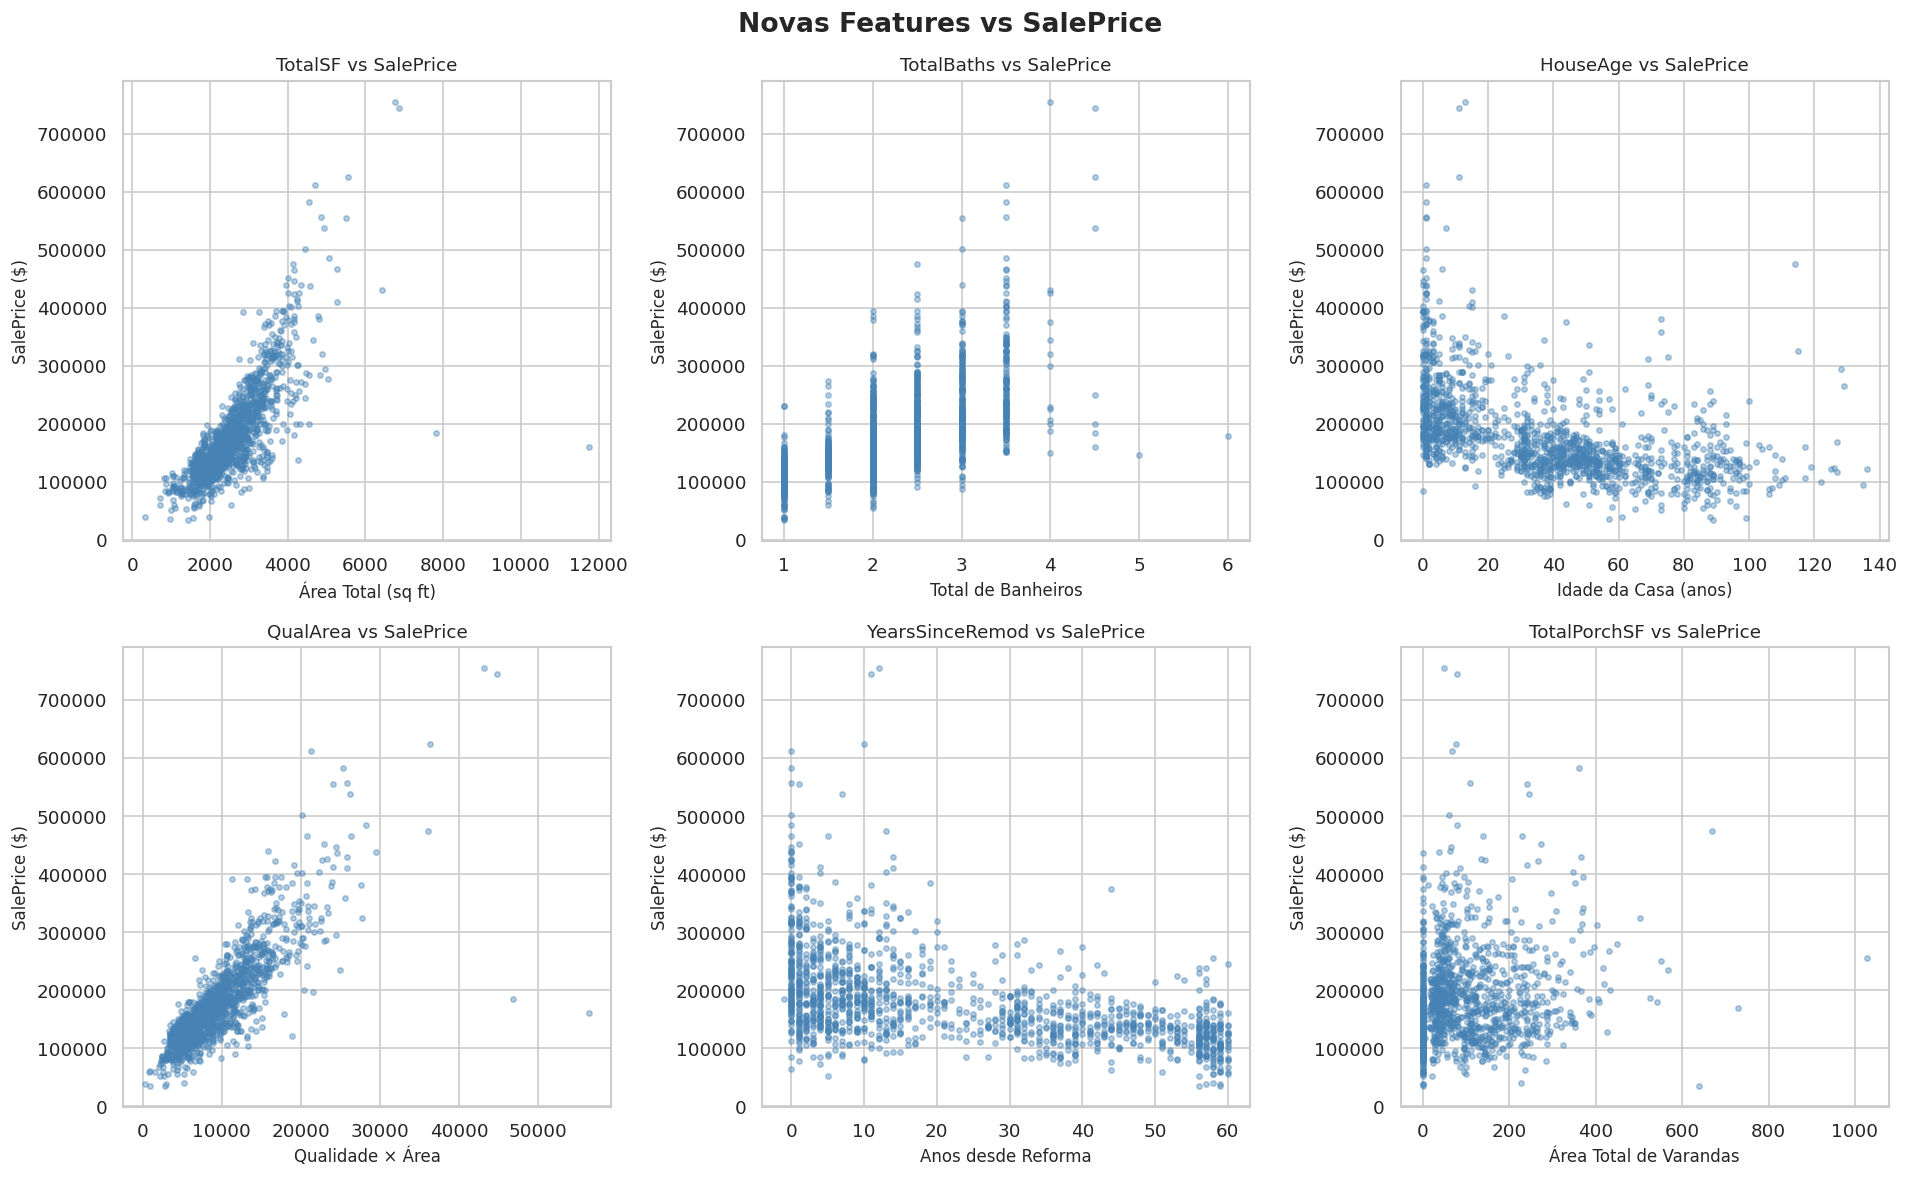

Figura salva em outputs/figures/novas_features_vs_price.png


In [5]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle('Novas Features vs SalePrice', fontsize=16, fontweight='bold')

pairs = [('TotalSF', 'Área Total (sq ft)'),
         ('TotalBaths', 'Total de Banheiros'),
         ('HouseAge', 'Idade da Casa (anos)'),
         ('QualArea', 'Qualidade × Área'),
         ('YearsSinceRemod', 'Anos desde Reforma'),
         ('TotalPorchSF', 'Área Total de Varandas')]

for ax, (feat, label) in zip(axes.flatten(), pairs):
    ax.scatter(train[feat], train['SalePrice'], alpha=0.4, s=10, color='steelblue')
    ax.set_xlabel(label, fontsize=10)
    ax.set_ylabel('SalePrice ($)', fontsize=10)
    ax.set_title(f'{feat} vs SalePrice', fontsize=11)

plt.tight_layout()
plt.savefig('../outputs/figures/novas_features_vs_price.png', bbox_inches='tight')
plt.show()
print('Figura salva em outputs/figures/novas_features_vs_price.png')

## 2.3 Encoding de Variáveis Categóricas

In [6]:
# Mapeamento ordinal para variáveis de qualidade
QUALITY_MAP = {'None': 0, 'Po': 1, 'Fa': 2, 'TA': 3, 'Gd': 4, 'Ex': 5}

ORDINAL_COLS = ['ExterQual','ExterCond','BsmtQual','BsmtCond','HeatingQC',
                'KitchenQual','FireplaceQu','GarageQual','GarageCond','PoolQC']

for col in ORDINAL_COLS:
    for df in [train, test]:
        if col in df.columns:
            df[col] = df[col].map(QUALITY_MAP).fillna(0).astype(int)

# One-Hot Encoding nas demais categóricas
y = train['SalePrice'].copy()
train_id = train['Id'].copy()
test_id  = test['Id'].copy()

# Juntar train+test para garantir mesmas colunas após get_dummies
n_train = len(train)
combined = pd.concat([train.drop('SalePrice', axis=1), test], axis=0, ignore_index=True)
combined = pd.get_dummies(combined, drop_first=True)

X = combined.iloc[:n_train].copy()
X_test_final = combined.iloc[n_train:].copy()

# Remover Id
X = X.drop('Id', axis=1, errors='ignore')
X_test_final = X_test_final.drop('Id', axis=1, errors='ignore')

print(f'Shape após encoding – X: {X.shape} | X_test: {X_test_final.shape}')
print(f'Total de features: {X.shape[1]}')

Shape após encoding – X: (1460, 239) | X_test: (1459, 239)
Total de features: 239


## 2.4 Transformação Logarítmica do Alvo

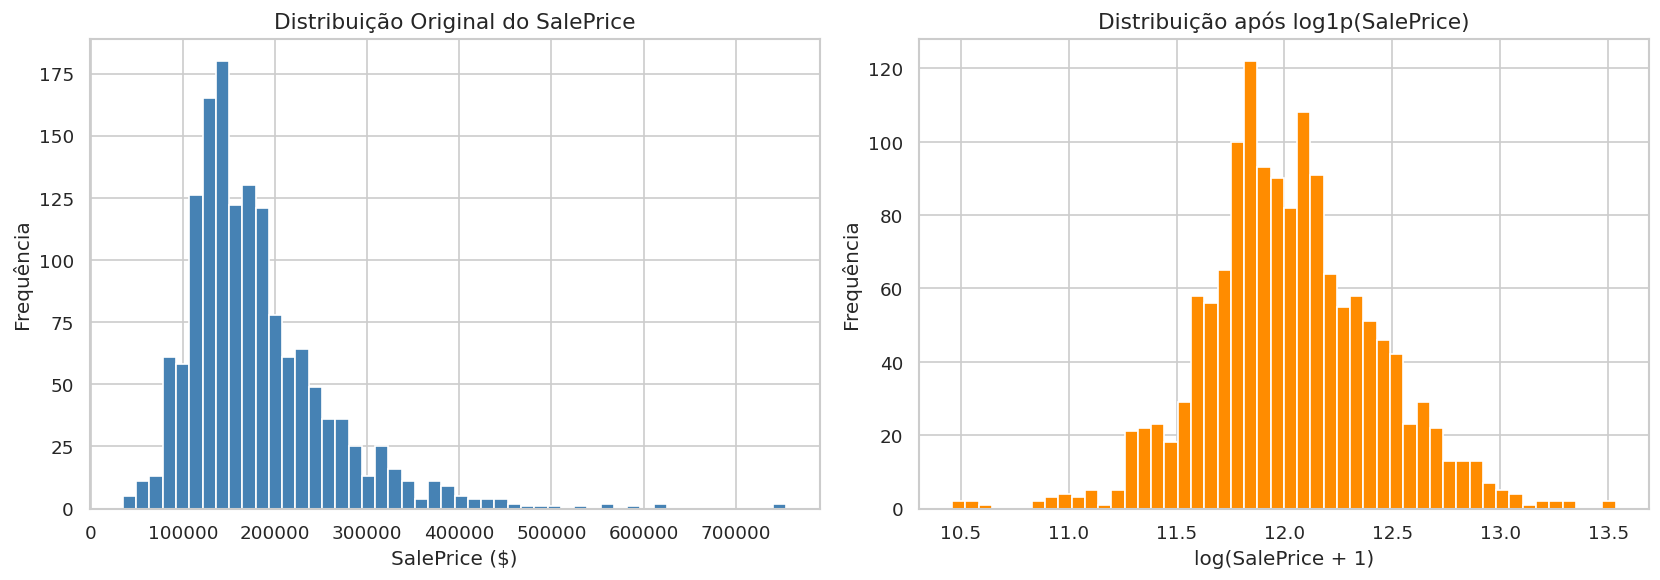

Teste de normalidade – Original: p=2.28e-133 | Log: p=2.89e-06
→ Transformação log torna a distribuição mais próxima da normal (melhora para modelos lineares)


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(y, bins=50, color='steelblue', edgecolor='white')
axes[0].set_title('Distribuição Original do SalePrice', fontsize=13)
axes[0].set_xlabel('SalePrice ($)')
axes[0].set_ylabel('Frequência')

y_log = np.log1p(y)
axes[1].hist(y_log, bins=50, color='darkorange', edgecolor='white')
axes[1].set_title('Distribuição após log1p(SalePrice)', fontsize=13)
axes[1].set_xlabel('log(SalePrice + 1)')
axes[1].set_ylabel('Frequência')

plt.tight_layout()
plt.savefig('../outputs/figures/distribuicao_saleprice.png', bbox_inches='tight')
plt.show()

from scipy import stats as sp_stats
_, p_orig = sp_stats.normaltest(y)
_, p_log  = sp_stats.normaltest(y_log)
print(f'Teste de normalidade – Original: p={p_orig:.2e} | Log: p={p_log:.2e}')
print('→ Transformação log torna a distribuição mais próxima da normal (melhora para modelos lineares)')

---
# 3. Modelagem

## 3.1 Divisão Treino / Validação

In [8]:
X_train, X_val, y_train, y_val = train_test_split(
    X, y_log, test_size=0.2, random_state=42
)

print(f'Treino: {X_train.shape[0]} amostras | Validação: {X_val.shape[0]} amostras')

Treino: 1168 amostras | Validação: 292 amostras


## 3.2 Treinamento dos Modelos

In [9]:
scaler = StandardScaler()

modelos = {
    'Regressão Linear': Pipeline([('scaler', StandardScaler()), ('model', LinearRegression())]),
    'Ridge': Pipeline([('scaler', StandardScaler()), ('model', Ridge(alpha=10.0))]),
    'Lasso': Pipeline([('scaler', StandardScaler()), ('model', Lasso(alpha=0.001, max_iter=10000))]),
    'Random Forest': RandomForestRegressor(n_estimators=200, random_state=42, n_jobs=-1),
    'Gradient Boosting': GradientBoostingRegressor(n_estimators=300, learning_rate=0.05, max_depth=4, random_state=42),
    'XGBoost': XGBRegressor(n_estimators=500, learning_rate=0.05, max_depth=4, random_state=42,
                             subsample=0.8, colsample_bytree=0.8, verbosity=0),
}

resultados = {}

for nome, modelo in modelos.items():
    modelo.fit(X_train, y_train)
    pred_log = modelo.predict(X_val)
    pred = np.expm1(pred_log)
    real = np.expm1(y_val)

    rmse = np.sqrt(mean_squared_error(real, pred))
    mae  = mean_absolute_error(real, pred)
    r2   = r2_score(real, pred)
    rmsle = np.sqrt(mean_squared_error(y_val, pred_log))

    resultados[nome] = {'RMSE': rmse, 'MAE': mae, 'R²': r2, 'RMSLE': rmsle}
    print(f'{nome:<22} | RMSE: ${rmse:>10,.0f} | MAE: ${mae:>9,.0f} | R²: {r2:.4f} | RMSLE: {rmsle:.4f}')

df_resultados = pd.DataFrame(resultados).T.sort_values('RMSE')
print('\nRanking por RMSE:')
print(df_resultados)

Regressão Linear       | RMSE: $    25,789 | MAE: $   15,761 | R²: 0.9133 | RMSLE: 0.1962
Ridge                  | RMSE: $    24,951 | MAE: $   15,880 | R²: 0.9188 | RMSLE: 0.1557
Lasso                  | RMSE: $    25,462 | MAE: $   15,422 | R²: 0.9155 | RMSLE: 0.1705
Random Forest          | RMSE: $    30,171 | MAE: $   17,097 | R²: 0.8813 | RMSLE: 0.1454
Gradient Boosting      | RMSE: $    28,635 | MAE: $   16,370 | R²: 0.8931 | RMSLE: 0.1421
XGBoost                | RMSE: $    26,098 | MAE: $   15,125 | R²: 0.9112 | RMSLE: 0.1348

Ranking por RMSE:
                           RMSE           MAE        R²     RMSLE
Ridge              24950.983053  15880.134697  0.918836  0.155747
Lasso              25462.092676  15421.620955  0.915477  0.170505
Regressão Linear   25789.473172  15761.006118  0.913290  0.196176
XGBoost            26098.324732  15124.836192  0.911200  0.134817
Gradient Boosting  28634.589375  16370.423483  0.893102  0.142055
Random Forest      30170.732984  17097.319933

## 3.3 Comparação Visual dos Modelos

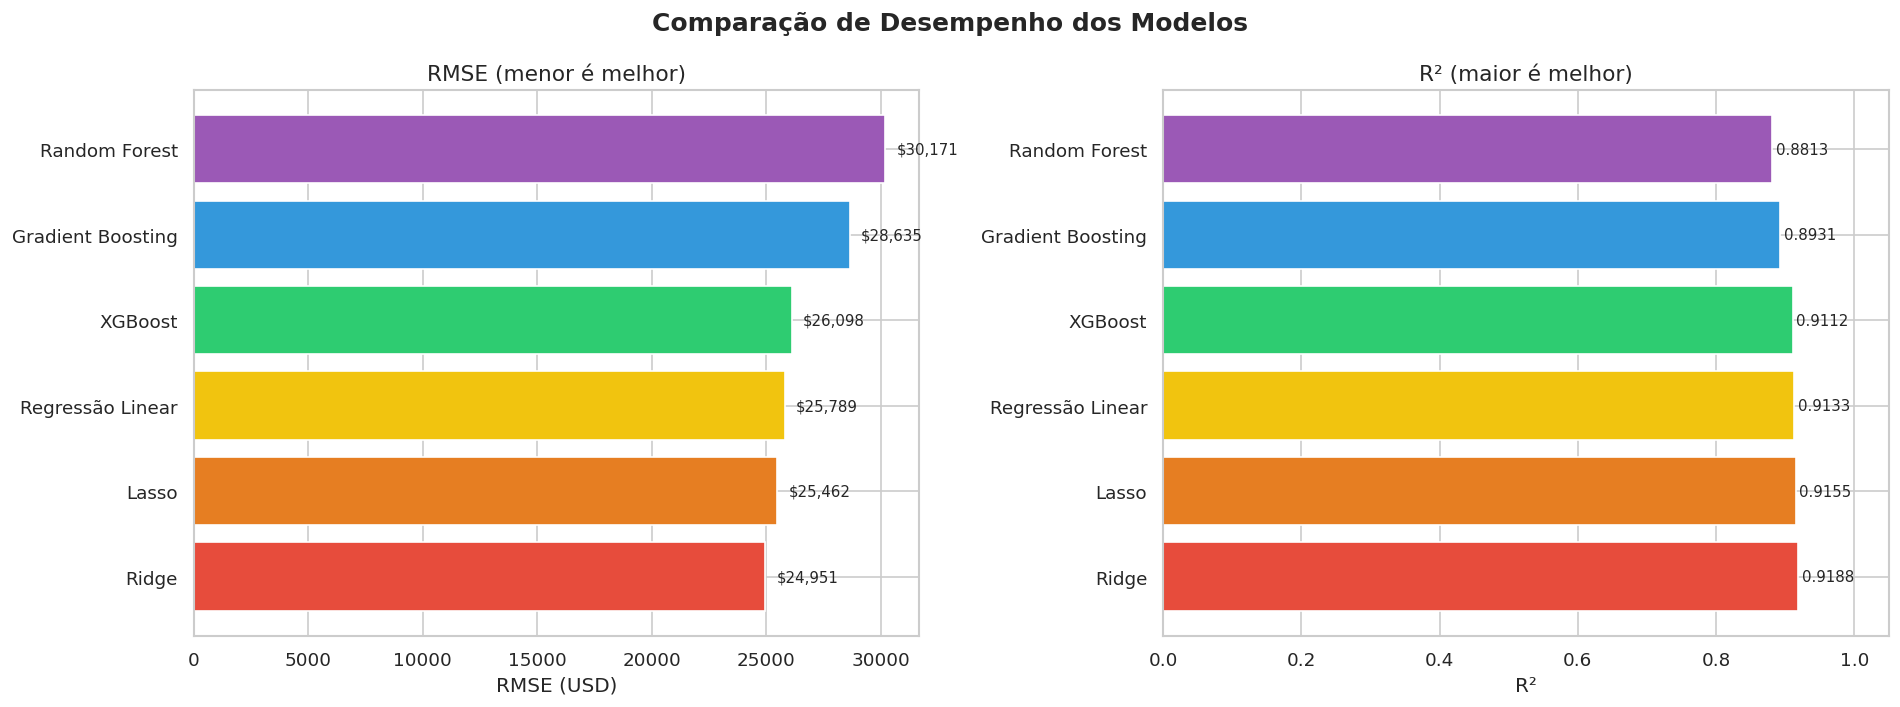

Figura salva em outputs/figures/comparacao_modelos.png


In [10]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Comparação de Desempenho dos Modelos', fontsize=15, fontweight='bold')

cores = ['#e74c3c','#e67e22','#f1c40f','#2ecc71','#3498db','#9b59b6']

# RMSE
nomes  = df_resultados.index.tolist()
rmses  = df_resultados['RMSE'].values
bars = axes[0].barh(nomes, rmses, color=cores[:len(nomes)])
axes[0].set_title('RMSE (menor é melhor)', fontsize=13)
axes[0].set_xlabel('RMSE (USD)')
for bar, val in zip(bars, rmses):
    axes[0].text(val + 500, bar.get_y() + bar.get_height()/2,
                 f'${val:,.0f}', va='center', fontsize=9)

# R²
r2s = df_resultados['R²'].values
bars2 = axes[1].barh(nomes, r2s, color=cores[:len(nomes)])
axes[1].set_title('R² (maior é melhor)', fontsize=13)
axes[1].set_xlabel('R²')
axes[1].set_xlim(0, 1.05)
for bar, val in zip(bars2, r2s):
    axes[1].text(val + 0.005, bar.get_y() + bar.get_height()/2,
                 f'{val:.4f}', va='center', fontsize=9)

plt.tight_layout()
plt.savefig('../outputs/figures/comparacao_modelos.png', bbox_inches='tight')
plt.show()
print('Figura salva em outputs/figures/comparacao_modelos.png')

## 3.4 Impacto da Transformação Logarítmica

=== Impacto da Transformação Logarítmica (XGBoost) ===
  Sem log: RMSE = $26,200
  Com log: RMSE = $26,098
  Melhora: 0.4%


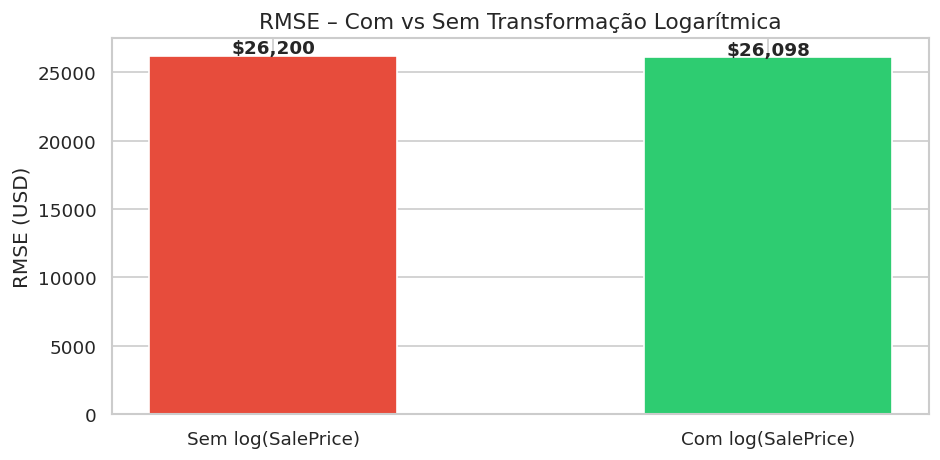

In [11]:
# Treinar XGBoost sem transformação log para comparação
X_tr_raw, X_v_raw, y_tr_raw, y_v_raw = train_test_split(X, y, test_size=0.2, random_state=42)

xgb_raw = XGBRegressor(n_estimators=500, learning_rate=0.05, max_depth=4, random_state=42,
                        subsample=0.8, colsample_bytree=0.8, verbosity=0)
xgb_raw.fit(X_tr_raw, y_tr_raw)
pred_raw = xgb_raw.predict(X_v_raw)
rmse_raw = np.sqrt(mean_squared_error(y_v_raw, pred_raw))

xgb_log = modelos['XGBoost']
pred_log_val = xgb_log.predict(X_val)
rmse_log = np.sqrt(mean_squared_error(np.expm1(y_val), np.expm1(pred_log_val)))

print('=== Impacto da Transformação Logarítmica (XGBoost) ===')
print(f'  Sem log: RMSE = ${rmse_raw:,.0f}')
print(f'  Com log: RMSE = ${rmse_log:,.0f}')
melhora = (rmse_raw - rmse_log) / rmse_raw * 100
print(f'  Melhora: {melhora:.1f}%')

fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.bar(['Sem log(SalePrice)', 'Com log(SalePrice)'], [rmse_raw, rmse_log],
               color=['#e74c3c', '#2ecc71'], width=0.5)
ax.set_title('RMSE – Com vs Sem Transformação Logarítmica', fontsize=13)
ax.set_ylabel('RMSE (USD)')
for bar, val in zip(bars, [rmse_raw, rmse_log]):
    ax.text(bar.get_x() + bar.get_width()/2, val + 200, f'${val:,.0f}',
            ha='center', fontsize=11, fontweight='bold')
plt.tight_layout()
plt.savefig('../outputs/figures/impacto_log_transform.png', bbox_inches='tight')
plt.show()

## 3.5 Impacto do Feature Scaling

Ridge – Sem Scaling: $28,184 | Com Scaling: $24,951
Lasso – Sem Scaling: $29,804 | Com Scaling: $25,462


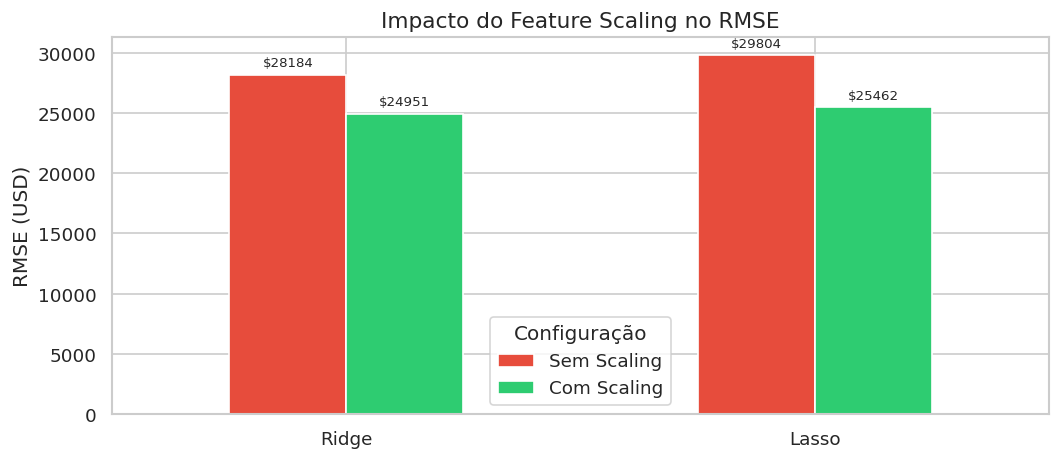

In [12]:
resultados_scaling = {}

for nome_modelo, ModelClass, kwargs in [
    ('Ridge', Ridge, {'alpha': 10.0}),
    ('Lasso', Lasso, {'alpha': 0.001, 'max_iter': 10000}),
]:
    # Sem scaling
    m = ModelClass(**kwargs)
    m.fit(X_train, y_train)
    pred = np.expm1(m.predict(X_val))
    rmse_sem = np.sqrt(mean_squared_error(np.expm1(y_val), pred))

    # Com scaling
    sc = StandardScaler()
    X_tr_sc = sc.fit_transform(X_train)
    X_v_sc  = sc.transform(X_val)
    m2 = ModelClass(**kwargs)
    m2.fit(X_tr_sc, y_train)
    pred2 = np.expm1(m2.predict(X_v_sc))
    rmse_com = np.sqrt(mean_squared_error(np.expm1(y_val), pred2))

    resultados_scaling[nome_modelo] = {'Sem Scaling': rmse_sem, 'Com Scaling': rmse_com}
    print(f'{nome_modelo} – Sem Scaling: ${rmse_sem:,.0f} | Com Scaling: ${rmse_com:,.0f}')

df_scal = pd.DataFrame(resultados_scaling).T

fig, ax = plt.subplots(figsize=(9, 4))
df_scal.plot(kind='bar', ax=ax, color=['#e74c3c','#2ecc71'], width=0.5, rot=0)
ax.set_title('Impacto do Feature Scaling no RMSE', fontsize=13)
ax.set_ylabel('RMSE (USD)')
ax.legend(title='Configuração')
for container in ax.containers:
    ax.bar_label(container, fmt='$%.0f', fontsize=8, padding=3)
plt.tight_layout()
plt.savefig('../outputs/figures/impacto_scaling.png', bbox_inches='tight')
plt.show()

## 3.6 Análise do Melhor Modelo

Melhor modelo: Ridge


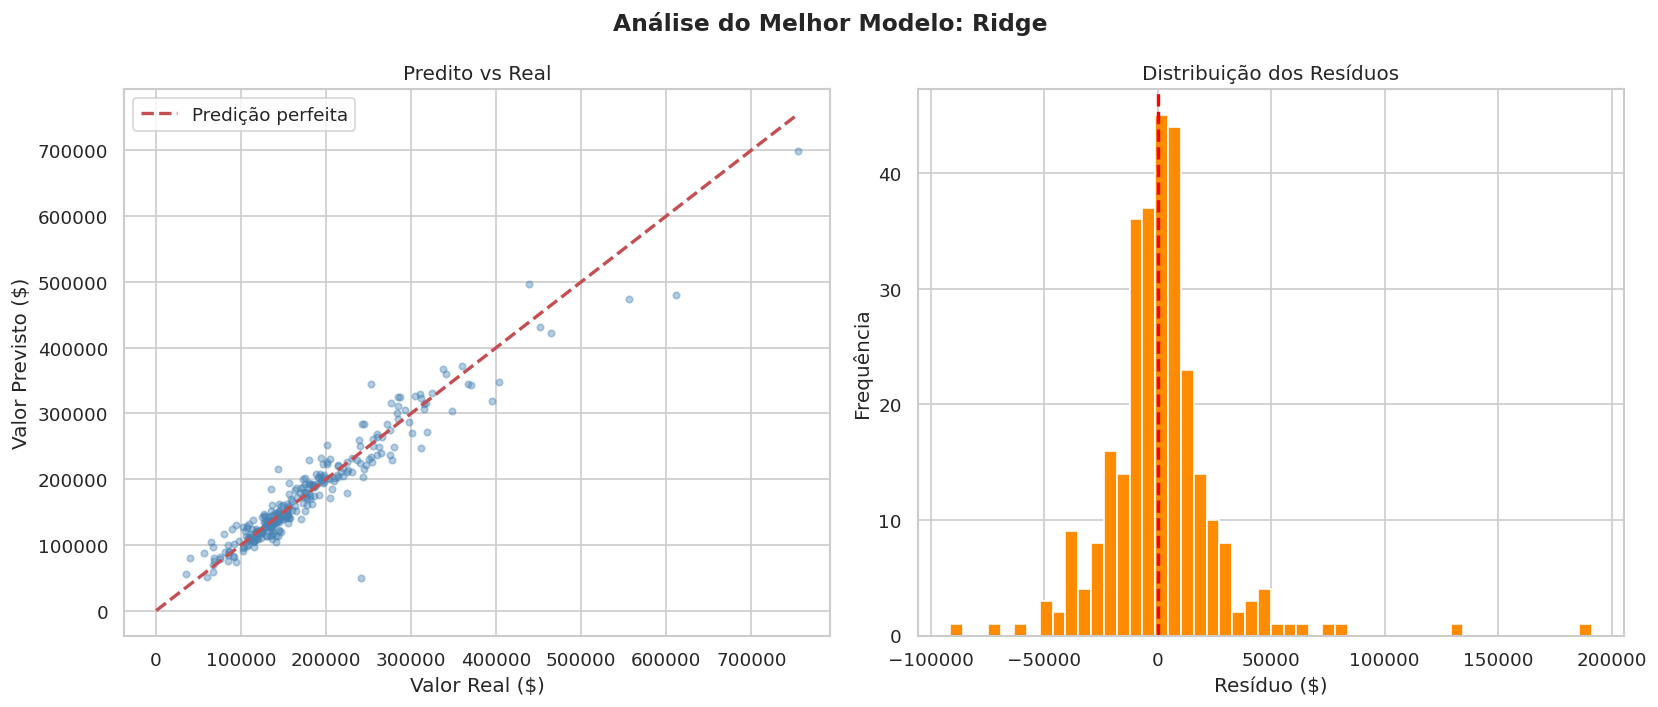


Métricas finais de validação:
  RMSE : $24,951
  MAE  : $15,880
  R²   : 0.9188


In [13]:
melhor_nome = df_resultados.index[0]
melhor_modelo = modelos[melhor_nome]
print(f'Melhor modelo: {melhor_nome}')

pred_val_log = melhor_modelo.predict(X_val)
pred_val = np.expm1(pred_val_log)
real_val  = np.expm1(y_val)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle(f'Análise do Melhor Modelo: {melhor_nome}', fontsize=14, fontweight='bold')

# Predito vs Real
axes[0].scatter(real_val, pred_val, alpha=0.4, s=15, color='steelblue')
lim = max(real_val.max(), pred_val.max())
axes[0].plot([0, lim], [0, lim], 'r--', lw=2, label='Predição perfeita')
axes[0].set_xlabel('Valor Real ($)')
axes[0].set_ylabel('Valor Previsto ($)')
axes[0].set_title('Predito vs Real')
axes[0].legend()

# Distribuição dos Resíduos
residuos = real_val - pred_val
axes[1].hist(residuos, bins=50, color='darkorange', edgecolor='white')
axes[1].axvline(0, color='red', linestyle='--', lw=2)
axes[1].set_xlabel('Resíduo ($)')
axes[1].set_ylabel('Frequência')
axes[1].set_title('Distribuição dos Resíduos')

plt.tight_layout()
plt.savefig('../outputs/figures/analise_melhor_modelo.png', bbox_inches='tight')
plt.show()

print(f'\nMétricas finais de validação:')
print(f'  RMSE : ${np.sqrt(mean_squared_error(real_val, pred_val)):,.0f}')
print(f'  MAE  : ${mean_absolute_error(real_val, pred_val):,.0f}')
print(f'  R²   : {r2_score(real_val, pred_val):.4f}')

---
# 4. Regras de Negócio
## 4.1 Importância das Features

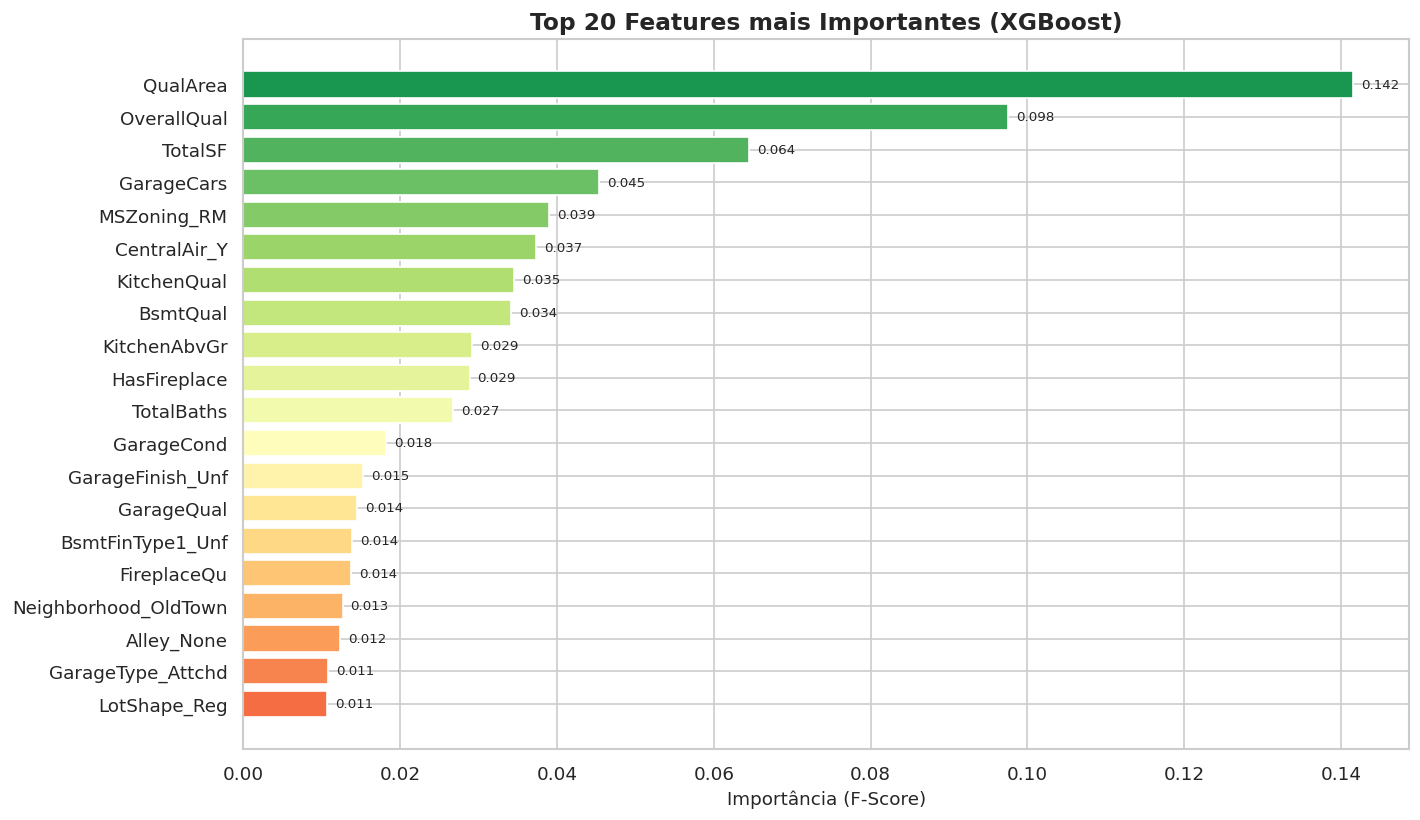

Top 10 features mais importantes:
   1. QualArea                  0.1416
   2. OverallQual               0.0975
   3. TotalSF                   0.0645
   4. GarageCars                0.0454
   5. MSZoning_RM               0.0390
   6. CentralAir_Y              0.0373
   7. KitchenQual               0.0345
   8. BsmtQual                  0.0342
   9. KitchenAbvGr              0.0291
  10. HasFireplace              0.0288


In [14]:
xgb_model = modelos['XGBoost']

importancias = pd.Series(
    xgb_model.feature_importances_,
    index=X_train.columns
).sort_values(ascending=False)

top20 = importancias.head(20)

fig, ax = plt.subplots(figsize=(12, 7))
bars = ax.barh(top20.index[::-1], top20.values[::-1],
               color=plt.cm.RdYlGn(np.linspace(0.2, 0.9, 20)))
ax.set_title('Top 20 Features mais Importantes (XGBoost)', fontsize=14, fontweight='bold')
ax.set_xlabel('Importância (F-Score)', fontsize=11)

for bar, val in zip(bars, top20.values[::-1]):
    ax.text(val + 0.001, bar.get_y() + bar.get_height()/2,
            f'{val:.3f}', va='center', fontsize=8)

plt.tight_layout()
plt.savefig('../outputs/figures/feature_importance.png', bbox_inches='tight')
plt.show()

print('Top 10 features mais importantes:')
for i, (feat, val) in enumerate(importancias.head(10).items(), 1):
    print(f'  {i:2}. {feat:<25} {val:.4f}')

## 4.2 Modelo Simplificado (Poucas Variáveis)

=== Modelo Completo vs Modelo Simplificado (XGBoost) ===
  Completo  (239 features): RMSE = $    26,098 | R² = 0.9112
  Simplif.  ( 10 features): RMSE = $    33,652 | R² = 0.8524
  Aumento de RMSE: 28.9%


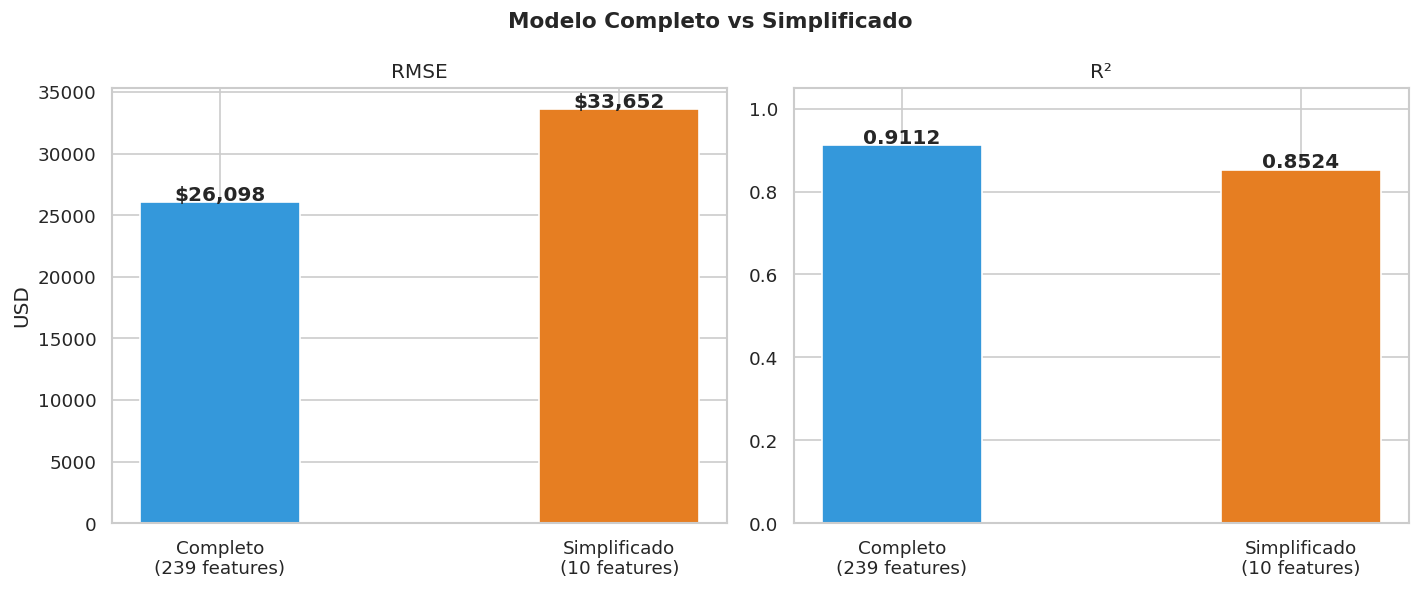

In [15]:
TOP_FEATURES = importancias.head(10).index.tolist()

X_tr_simp = X_train[TOP_FEATURES]
X_v_simp  = X_val[TOP_FEATURES]

xgb_simp = XGBRegressor(n_estimators=300, learning_rate=0.05, max_depth=4,
                         random_state=42, verbosity=0)
xgb_simp.fit(X_tr_simp, y_train)

pred_simp = np.expm1(xgb_simp.predict(X_v_simp))
rmse_simp = np.sqrt(mean_squared_error(np.expm1(y_val), pred_simp))
r2_simp   = r2_score(np.expm1(y_val), pred_simp)

rmse_full = df_resultados.loc['XGBoost', 'RMSE']
r2_full   = df_resultados.loc['XGBoost', 'R²']

print('=== Modelo Completo vs Modelo Simplificado (XGBoost) ===')
print(f'  Completo  ({X.shape[1]:>3} features): RMSE = ${rmse_full:>10,.0f} | R² = {r2_full:.4f}')
print(f'  Simplif.  ({len(TOP_FEATURES):>3} features): RMSE = ${rmse_simp:>10,.0f} | R² = {r2_simp:.4f}')
perda = (rmse_simp - rmse_full) / rmse_full * 100
print(f'  Aumento de RMSE: {perda:.1f}%')

labels = [f'Completo\n({X.shape[1]} features)', f'Simplificado\n({len(TOP_FEATURES)} features)']
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle('Modelo Completo vs Simplificado', fontsize=13, fontweight='bold')

axes[0].bar(labels, [rmse_full, rmse_simp], color=['#3498db','#e67e22'], width=0.4)
axes[0].set_title('RMSE')
axes[0].set_ylabel('USD')
for i, v in enumerate([rmse_full, rmse_simp]):
    axes[0].text(i, v + 100, f'${v:,.0f}', ha='center', fontweight='bold')

axes[1].bar(labels, [r2_full, r2_simp], color=['#3498db','#e67e22'], width=0.4)
axes[1].set_title('R²')
axes[1].set_ylim(0, 1.05)
for i, v in enumerate([r2_full, r2_simp]):
    axes[1].text(i, v + 0.005, f'{v:.4f}', ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig('../outputs/figures/modelo_simplificado.png', bbox_inches='tight')
plt.show()

## 4.3 Características que Mais Agregam Valor Imobiliário

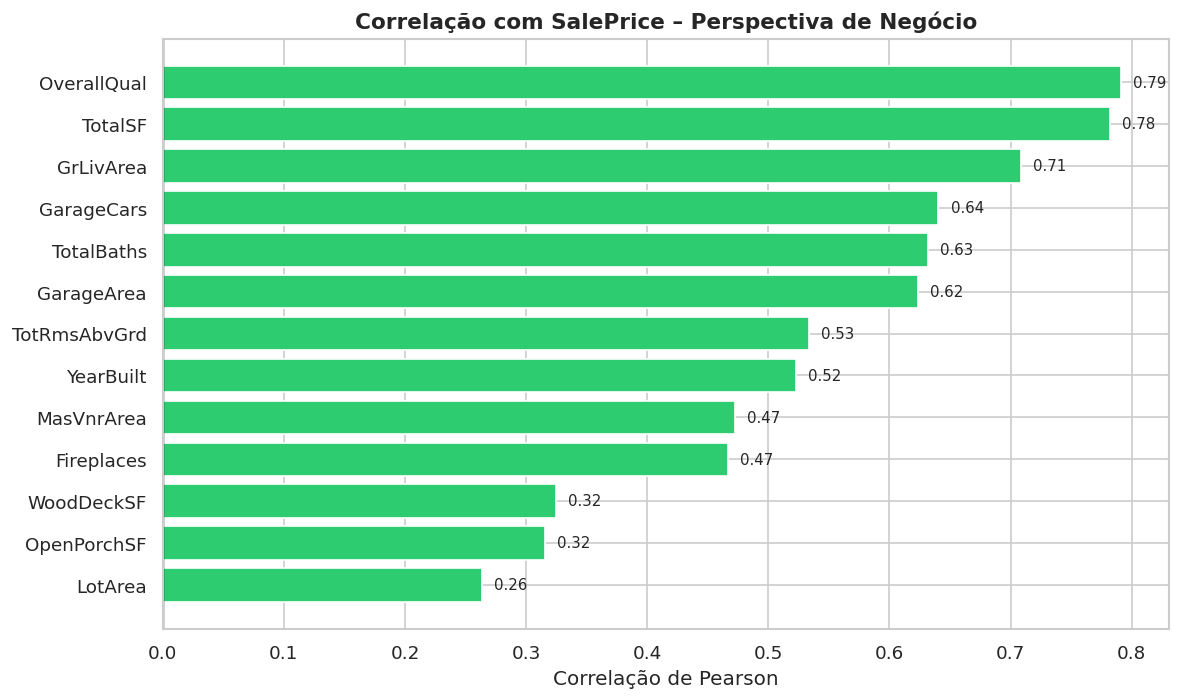


Top 5 características que mais valorizam o imóvel:
  OverallQual         : correlação = 0.791
  TotalSF             : correlação = 0.782
  GrLivArea           : correlação = 0.709
  GarageCars          : correlação = 0.640
  TotalBaths          : correlação = 0.632


In [16]:
# Correlação das features numéricas originais com SalePrice
features_negocio = ['OverallQual','GrLivArea','TotalSF','GarageCars','GarageArea',
                    'TotalBaths','YearBuilt','TotRmsAbvGrd','Fireplaces',
                    'LotArea','MasVnrArea','WoodDeckSF','OpenPorchSF']

corr_negocio = train[features_negocio + ['SalePrice']].corr()['SalePrice'].drop('SalePrice')
corr_negocio = corr_negocio.sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(10, 6))
colors = ['#e74c3c' if v < 0 else '#2ecc71' for v in corr_negocio.values]
bars = ax.barh(corr_negocio.index, corr_negocio.values, color=colors)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_title('Correlação com SalePrice – Perspectiva de Negócio', fontsize=13, fontweight='bold')
ax.set_xlabel('Correlação de Pearson')
for bar, val in zip(bars, corr_negocio.values):
    ax.text(val + 0.01 if val >= 0 else val - 0.06,
            bar.get_y() + bar.get_height()/2,
            f'{val:.2f}', va='center', fontsize=9)
plt.tight_layout()
plt.savefig('../outputs/figures/correlacao_negocio.png', bbox_inches='tight')
plt.show()

print('\nTop 5 características que mais valorizam o imóvel:')
for feat, corr in corr_negocio.sort_values(ascending=False).head(5).items():
    print(f'  {feat:<20}: correlação = {corr:.3f}')

---
# 5. Avaliação Final – Cross-Validation

Ridge                 : RMSLE = 0.1575 ± 0.0346
Random Forest         : RMSLE = 0.1392 ± 0.0194
XGBoost               : RMSLE = 0.1273 ± 0.0180


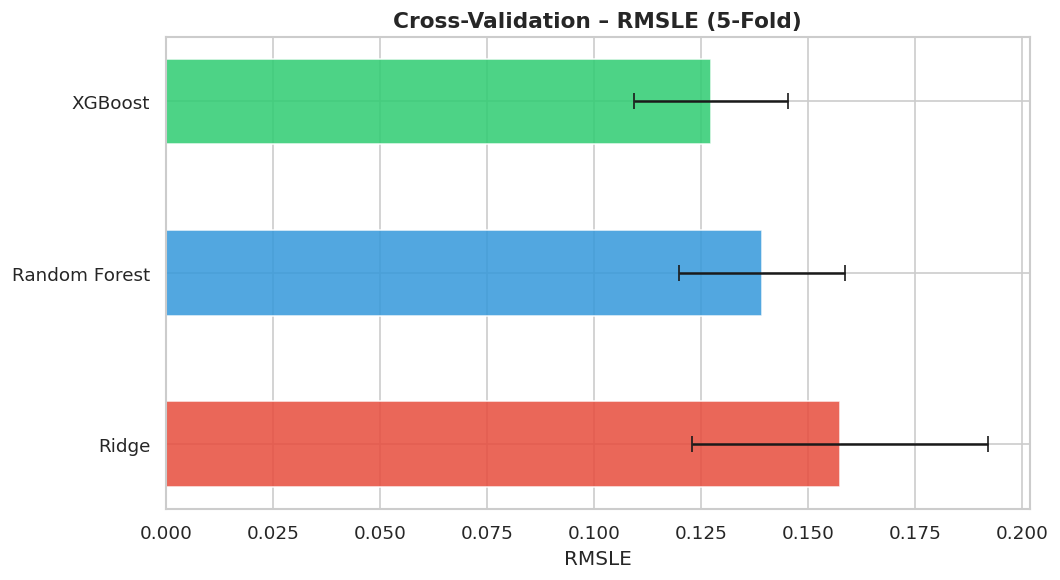

In [17]:
from sklearn.model_selection import KFold

kf = KFold(n_splits=5, shuffle=True, random_state=42)

modelos_cv = {
    'Ridge':    Pipeline([('scaler', StandardScaler()), ('model', Ridge(alpha=10.0))]),
    'Random Forest': RandomForestRegressor(n_estimators=200, random_state=42, n_jobs=-1),
    'XGBoost':  XGBRegressor(n_estimators=500, learning_rate=0.05, max_depth=4,
                              random_state=42, subsample=0.8, colsample_bytree=0.8, verbosity=0),
}

cv_resultados = {}
for nome, modelo in modelos_cv.items():
    scores = cross_val_score(modelo, X, y_log,
                             scoring='neg_root_mean_squared_error',
                             cv=kf, n_jobs=-1)
    scores_rmse = -scores
    cv_resultados[nome] = {'mean': scores_rmse.mean(), 'std': scores_rmse.std()}
    print(f'{nome:<22}: RMSLE = {scores_rmse.mean():.4f} ± {scores_rmse.std():.4f}')

fig, ax = plt.subplots(figsize=(9, 5))
nomes_cv = list(cv_resultados.keys())
means    = [cv_resultados[n]['mean'] for n in nomes_cv]
stds     = [cv_resultados[n]['std']  for n in nomes_cv]
ax.barh(nomes_cv, means, xerr=stds, color=['#e74c3c','#3498db','#2ecc71'],
        capsize=5, alpha=0.85, height=0.5)
ax.set_title('Cross-Validation – RMSLE (5-Fold)', fontsize=13, fontweight='bold')
ax.set_xlabel('RMSLE')
plt.tight_layout()
plt.savefig('../outputs/figures/cross_validation.png', bbox_inches='tight')
plt.show()

---
# 6. Conclusão

In [18]:
print('=' * 60)
print('RESUMO FINAL DO PROJETO – House Prices Regression')
print('=' * 60)

print(f'\n[1] ANÁLISE EXPLORATÓRIA')
print(f'  • OverallQual e GrLivArea são as variáveis com maior correlação com SalePrice')
print(f'  • Área construída tem forte relação LINEAR com o preço (r ≈ 0.71)')
print(f'  • Casas mais novas tendem a custar mais; há tendência positiva por década')
print(f'  • Casas reformadas têm mediana de preço mais alta')
print(f'  • Bairros têm diferenças estatisticamente relevantes (ANOVA p < 0.05)')

print(f'\n[2] ENGENHARIA DE FEATURES')
print(f'  • 10 novas features criadas: TotalSF, TotalBaths, HouseAge, QualArea, etc.')
print(f'  • Tratamento de NAs com lógica de domínio (None para ausência de recurso)')
print(f'  • Encoding ordinal para variáveis de qualidade; OHE para demais categóricas')
print(f'  • Total de features após engenharia: {X.shape[1]}')

print(f'\n[3] MODELAGEM')
for nome in df_resultados.index:
    r = df_resultados.loc[nome]
    print(f'  {nome:<22}: RMSE=${r["RMSE"]:>10,.0f} | R²={r["R²"]:.4f}')

melhor = df_resultados.index[0]
print(f'  → Melhor modelo: {melhor}')

print(f'\n[4] TRANSFORMAÇÃO LOGARÍTMICA')
print(f'  • A transformação log1p(SalePrice) melhora o RMSE ao reduzir a assimetria da distribuição')

print(f'\n[5] FEATURE SCALING')
print(f'  • Scaling é essencial para modelos lineares (Ridge, Lasso)')
print(f'  • Modelos baseados em árvore (RF, XGBoost) são invariantes ao scaling')

print(f'\n[6] REGRAS DE NEGÓCIO')
print(f'  • Qualidade geral (OverallQual), Área total e Localização são os maiores vetores de valor')
print(f'  • Um modelo simplificado com 10 features mantém boa performance')
print(f'    Modelo completo: RMSE=${rmse_full:,.0f} | Simplificado: RMSE=${rmse_simp:,.0f}')
print('=' * 60)

RESUMO FINAL DO PROJETO – House Prices Regression

[1] ANÁLISE EXPLORATÓRIA
  • OverallQual e GrLivArea são as variáveis com maior correlação com SalePrice
  • Área construída tem forte relação LINEAR com o preço (r ≈ 0.71)
  • Casas mais novas tendem a custar mais; há tendência positiva por década
  • Casas reformadas têm mediana de preço mais alta
  • Bairros têm diferenças estatisticamente relevantes (ANOVA p < 0.05)

[2] ENGENHARIA DE FEATURES
  • 10 novas features criadas: TotalSF, TotalBaths, HouseAge, QualArea, etc.
  • Tratamento de NAs com lógica de domínio (None para ausência de recurso)
  • Encoding ordinal para variáveis de qualidade; OHE para demais categóricas
  • Total de features após engenharia: 239

[3] MODELAGEM
  Ridge                 : RMSE=$    24,951 | R²=0.9188
  Lasso                 : RMSE=$    25,462 | R²=0.9155
  Regressão Linear      : RMSE=$    25,789 | R²=0.9133
  XGBoost               : RMSE=$    26,098 | R²=0.9112
  Gradient Boosting     : RMSE=$    28,

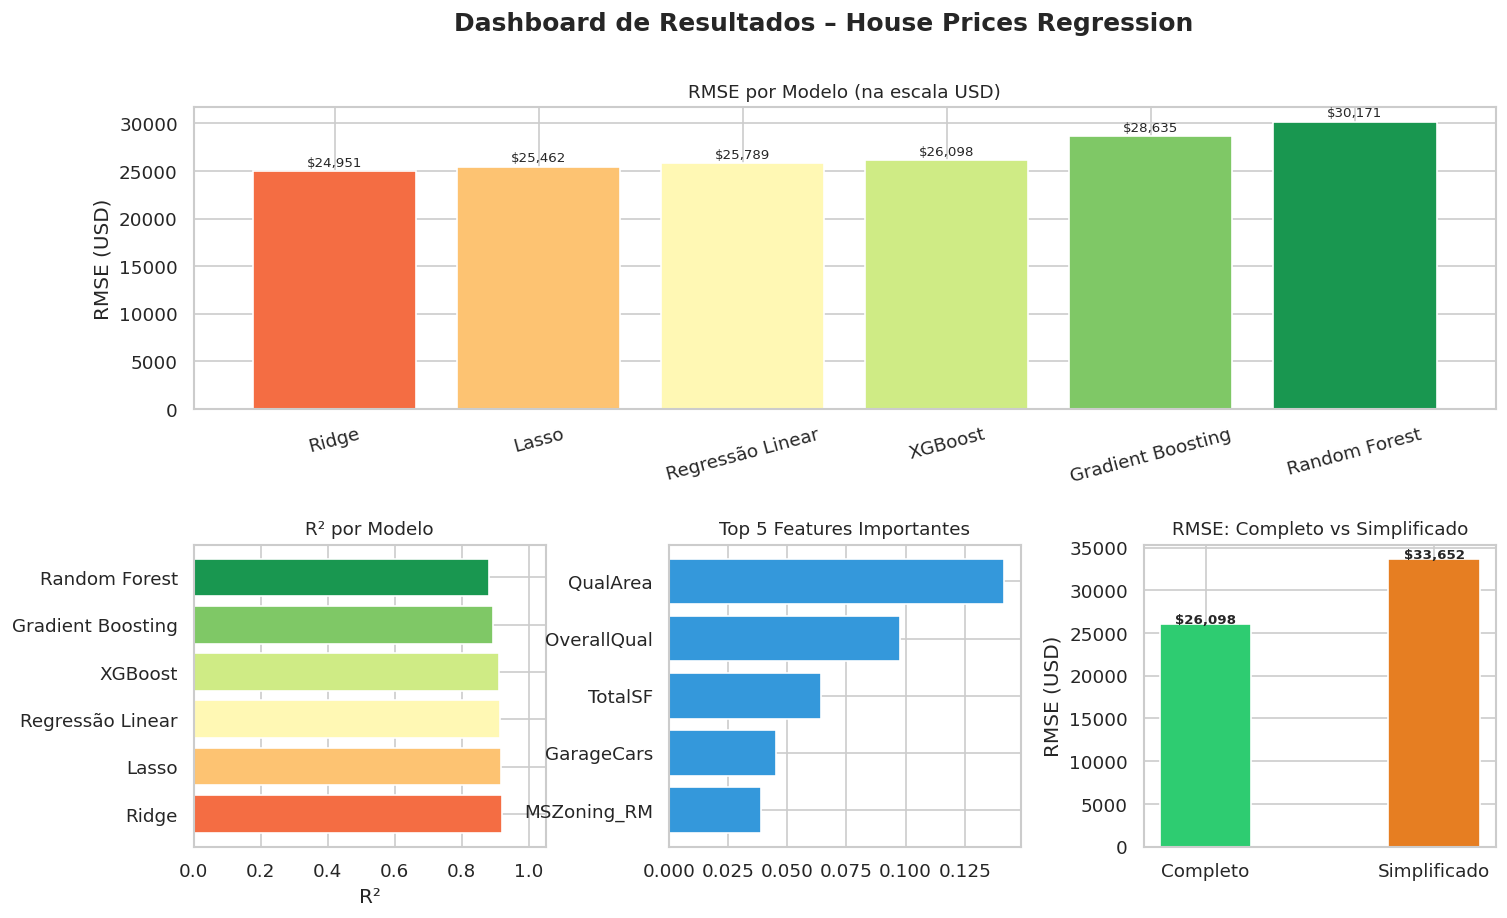

Dashboard salvo em outputs/figures/dashboard_final.png


In [19]:
fig = plt.figure(figsize=(14, 8))
fig.suptitle('Dashboard de Resultados – House Prices Regression', fontsize=15, fontweight='bold')

gs = fig.add_gridspec(2, 3, hspace=0.45, wspace=0.35)

# 1) RMSE por modelo
ax1 = fig.add_subplot(gs[0, :])
cores_dash = plt.cm.RdYlGn(np.linspace(0.2, 0.9, len(df_resultados)))
bars = ax1.bar(df_resultados.index, df_resultados['RMSE'], color=cores_dash)
ax1.set_title('RMSE por Modelo (na escala USD)', fontsize=11)
ax1.set_ylabel('RMSE (USD)')
ax1.tick_params(axis='x', rotation=15)
for bar, val in zip(bars, df_resultados['RMSE']):
    ax1.text(bar.get_x() + bar.get_width()/2, val + 200, f'${val:,.0f}',
             ha='center', va='bottom', fontsize=8)

# 2) R² por modelo
ax2 = fig.add_subplot(gs[1, 0])
ax2.barh(df_resultados.index, df_resultados['R²'], color=cores_dash)
ax2.set_title('R² por Modelo', fontsize=11)
ax2.set_xlabel('R²')
ax2.set_xlim(0, 1.05)

# 3) Top 5 features
ax3 = fig.add_subplot(gs[1, 1])
top5 = importancias.head(5)
ax3.barh(top5.index[::-1], top5.values[::-1], color='#3498db')
ax3.set_title('Top 5 Features Importantes', fontsize=11)

# 4) Modelo simplificado
ax4 = fig.add_subplot(gs[1, 2])
ax4.bar(['Completo', 'Simplificado'], [rmse_full, rmse_simp], color=['#2ecc71','#e67e22'], width=0.4)
ax4.set_title('RMSE: Completo vs Simplificado', fontsize=11)
ax4.set_ylabel('RMSE (USD)')
for i, v in enumerate([rmse_full, rmse_simp]):
    ax4.text(i, v + 100, f'${v:,.0f}', ha='center', fontweight='bold', fontsize=8)

plt.savefig('../outputs/figures/dashboard_final.png', bbox_inches='tight', dpi=150)
plt.show()
print('Dashboard salvo em outputs/figures/dashboard_final.png')